# Assignment 3: Discrete Delta Hedging under Proportional Transaction Costs

## Introduction

**Objective:**
The primary objective of this assignment is to break the frictionless market assumption of the Black-Scholes-Merton (BSM) framework by introducing proportional transaction costs. We will empirically analyze how these market frictions impact the self-financing replicating portfolio. By documenting the mean and standard deviation of the terminal replication error ($w_T$) across varying rebalancing frequencies, we aim to expose the fundamental mathematical tension between hedging risk (variance) and transaction costs (bleed).

**Mathematical Methodology:**
As established previously, we partition the continuous time horizon $[0, T]$ into $M$ discrete sub-intervals over the grid:
$$0 = t_0 < t_1 < \dots < t_M = T$$

We introduce a proportional transaction cost rate $k$. Buying or selling $|\Delta x|$ shares at a spot price $S_t$ now incurs an explicit fee of $k |\Delta x| S_t$. 

This fundamentally alters the wealth dynamics of the risk-free cash account $y$. At each rebalancing step $t_k$, the cash account accrues interest, funds the purchase/sale of the underlying asset, and pays the transaction fee. The recursive dynamic for the cash account becomes:
$$y_{t_k} = y_{t_{k-1}} e^{r(t_k - t_{k-1})} - (\Delta_k - x_{t_{k-1}}) S_{t_k} - k |\Delta_k - x_{t_{k-1}}| S_{t_k}$$

Where $\Delta_k = \Phi(d_1(t_k, S_{t_k}))$ is the target BSM delta, and $x_{t_{k-1}}$ is the inherited stock position from the previous period.

At maturity ($t_M = T$), after executing the final rebalancing trade to match the terminal delta boundary condition ($\Delta_M \in \{0, 1\}$), the terminal replication error is evaluated as:
$$w_T = x_{t_M} S_T + y_{t_M} - \max(S_T - K, 0)$$

In a frictionless market, $\mathbb{E}[w_T] = 0$. With transaction costs, the continuous extraction of capital implies $\mathbb{E}[w_T] < 0$.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Professional plotting style for academic presentation
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.figsize'] = (10, 6)

## Part (a): Modifying the Hedging Algorithm for Market Frictions(Transaction costs)

**What we are doing:**
We are defining the programmatic logic for the market maker's trading algorithm over the life of one option. 

**Modifications from Frictionless Models:**
The `discrete_delta_hedge_with_costs` function builds upon standard discrete hedging but introduces a critical modification to the cash account update logic. 
1. **Trade Quantity:** We calculate exactly how many shares must be traded to reach the target Delta: `trade_qty = delta_k - x`.
2. **Friction Cost Penalty:** We apply the absolute value of the trade quantity to calculate the fee: `friction_cost = k_cost * np.abs(trade_qty) * S_k`.
3. **Cash Bleed:** The cash account ($y$) earns interest, pays for the shares, and is explicitly penalized by the `friction_cost`.

*(Note: We retain 'guardrails' at $t = T$ ($\tau \le 1\times10^{-9}$) to prevent the Black-Scholes formulas from dividing by zero at the exact moment of expiration, forcing the Delta to cleanly resolve to $1.0$ or $0.0$.)*

In [12]:
def bs_call_price(S, K, r, sigma, T, t):
    """Computes the analytical Black-Scholes European Call price."""
    tau = T - t
    if tau <= 1e-9: # Guard against floating point singularity at expiration
        return np.maximum(S - K, 0.0)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

def bs_delta(S, K, r, sigma, T, t):
    """Computes the analytical Black-Scholes Delta."""
    tau = T - t
    if tau <= 1e-9: # Guard against gamma explosion/singularity at expiration
        return 1.0 if S > K else 0.0
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)
def discrete_delta_hedge_with_costs(path, K, r, sigma, T, rebal_times, k_cost):
    """
    Simulates a discrete delta hedge with proportional transaction costs.
    Stops rebalancing at t_{M-1} to avoid terminal Gamma explosion.
    """
    M = len(rebal_times) - 1
    S0 = path[0]
    
    # Initialization at t=0
    C0 = bs_call_price(S0, K, r, sigma, T, 0.0)
    x = 0.0     
    y = C0      
    
    # FIX: Loop strictly executes M times (from k=0 to k=M-1)
    # We do NOT rebalance at t_M = T to avoid infinite transaction costs
    for k in range(M):
        t_k = rebal_times[k]
        S_k = path[k]
        
        delta_k = bs_delta(S_k, K, r, sigma, T, t_k)
        dt = 0.0 if k == 0 else (rebal_times[k] - rebal_times[k-1])
        
        trade_qty = delta_k - x
        capital_flow = trade_qty * S_k
        friction_cost = k_cost * np.abs(trade_qty) * S_k
        
        y = y * np.exp(r * dt) - capital_flow - friction_cost
        x = delta_k
        
    # At maturity t_M = T, we simply liquidate the carried-over position
    # 1. Accrue interest on the cash account for the final unhedged interval
    dt_final = rebal_times[M] - rebal_times[M-1]
    y_T = y * np.exp(r * dt_final)
    
    # 2. Liquidate shares and pay option payoff
    S_T = path[M]
    payoff = np.maximum(S_T - K, 0.0)
    
    w_T = x * S_T + y_T - payoff
    
    return w_T


### Visual Deliverable: Anatomy of the Financial Bleed on a Single Path

Before running thousands of simulations, we must visually verify how transaction costs impact the portfolio in real-time. 

**What we are doing:** We generate a single, deterministic stock path. We run our modified hedging engine and plot three panels:
1. **Value Tracking:** How well the discrete portfolio tracks the theoretical option value.
2. **Delta Position:** The step-by-step trading of shares.
3. **Cumulative Cost (New):** A visualization of the explicit capital being drained from the cash account due to the $k=0.01$ fee structure.

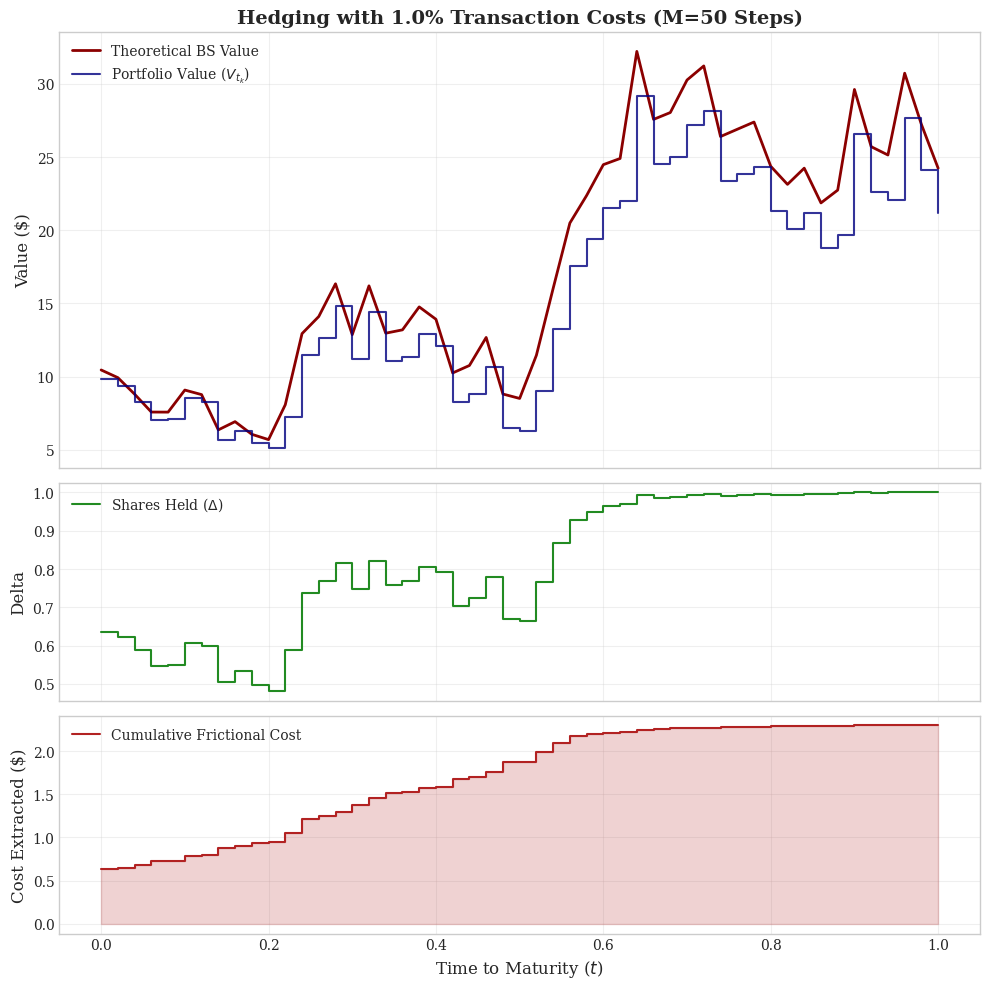

In [13]:
def plot_single_path_with_costs(S0, K, r, sigma, T, M, k_cost):
    np.random.seed(105) # Seed chosen to force an ATM crossing to highlight trading volume
    
    rebal_times = np.linspace(0, T, M + 1)
    dt = T / M
    Z = np.random.standard_normal(M)
    path = np.zeros(M + 1)
    path[0] = S0
    for k in range(1, M + 1):
        path[k] = path[k-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[k-1])
        
    port_values, bs_values, deltas, cumulative_costs = np.zeros(M+1), np.zeros(M+1), np.zeros(M+1), np.zeros(M+1)
    
    C0 = bs_call_price(path[0], K, r, sigma, T, 0.0)
    x, y, total_bleed = 0.0, C0, 0.0
    
    for k in range(M + 1):
        t_k = rebal_times[k]
        S_k = path[k]
        
        bs_values[k] = bs_call_price(S_k, K, r, sigma, T, t_k)
        delta_k = bs_delta(S_k, K, r, sigma, T, t_k)
        deltas[k] = delta_k
        
        step_dt = 0.0 if k == 0 else (rebal_times[k] - rebal_times[k-1])
        trade_qty = delta_k - x
        friction = k_cost * np.abs(trade_qty) * S_k
        total_bleed += friction
        cumulative_costs[k] = total_bleed
        
        y = y * np.exp(r * step_dt) - (trade_qty * S_k) - friction
        x = delta_k
        port_values[k] = x * S_k + y

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1, 1]}, sharex=True)
    
    # Panel 1: Portfolio Tracking
    ax1.plot(rebal_times, bs_values, color='darkred', linewidth=2, label='Theoretical BS Value')
    ax1.step(rebal_times, port_values, where='post', color='navy', alpha=0.8, label=r'Portfolio Value ($V_{t_k}$)')
    ax1.set_title(f'Hedging with {k_cost*100}% Transaction Costs (M={M} Steps)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Value ($)', fontsize=12)
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Delta
    ax2.step(rebal_times, deltas, where='post', color='forestgreen', label=r'Shares Held ($\Delta$)')
    ax2.set_ylabel('Delta', fontsize=12)
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Cost Bleed
    ax3.step(rebal_times, cumulative_costs, where='post', color='firebrick', label='Cumulative Frictional Cost')
    ax3.fill_between(rebal_times, cumulative_costs, step='post', color='firebrick', alpha=0.2)
    ax3.set_xlabel('Time to Maturity ($t$)', fontsize=12)
    ax3.set_ylabel('Cost Extracted ($)', fontsize=12)
    ax3.legend(loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_single_path_with_costs(S0=100.0, K=100.0, r=0.05, sigma=0.20, T=1.0, M=50, k_cost=0.01)

## Part (b): Monte Carlo Simulation and Distribution Shift

**What we are doing:**
A single path does not provide statistical certainty. We now scale the experiment to a Monte Carlo simulation.
1. We generate $N=1000$ independent random stock paths.
2. We test four different rebalancing frequencies: $M \in \{10, 50, 250, 1000\}$ trades per year.
3. We run the $1000$ paths through our frictional hedging engine and record the terminal error $w_T$.

**Expected Observation (The Negative Shift):**
In a zero-cost world, the distribution of $w_T$ is centered exactly at $0$ (unbiased). With a cost rate of $k=0.01$, every trade drains cash. As $M$ increases, the algorithm trades more frequently. Therefore, we expect the mean error ($\mathbb{E}[w_T]$) to violently shift into negative territory, indicating mounting, inevitable portfolio losses.

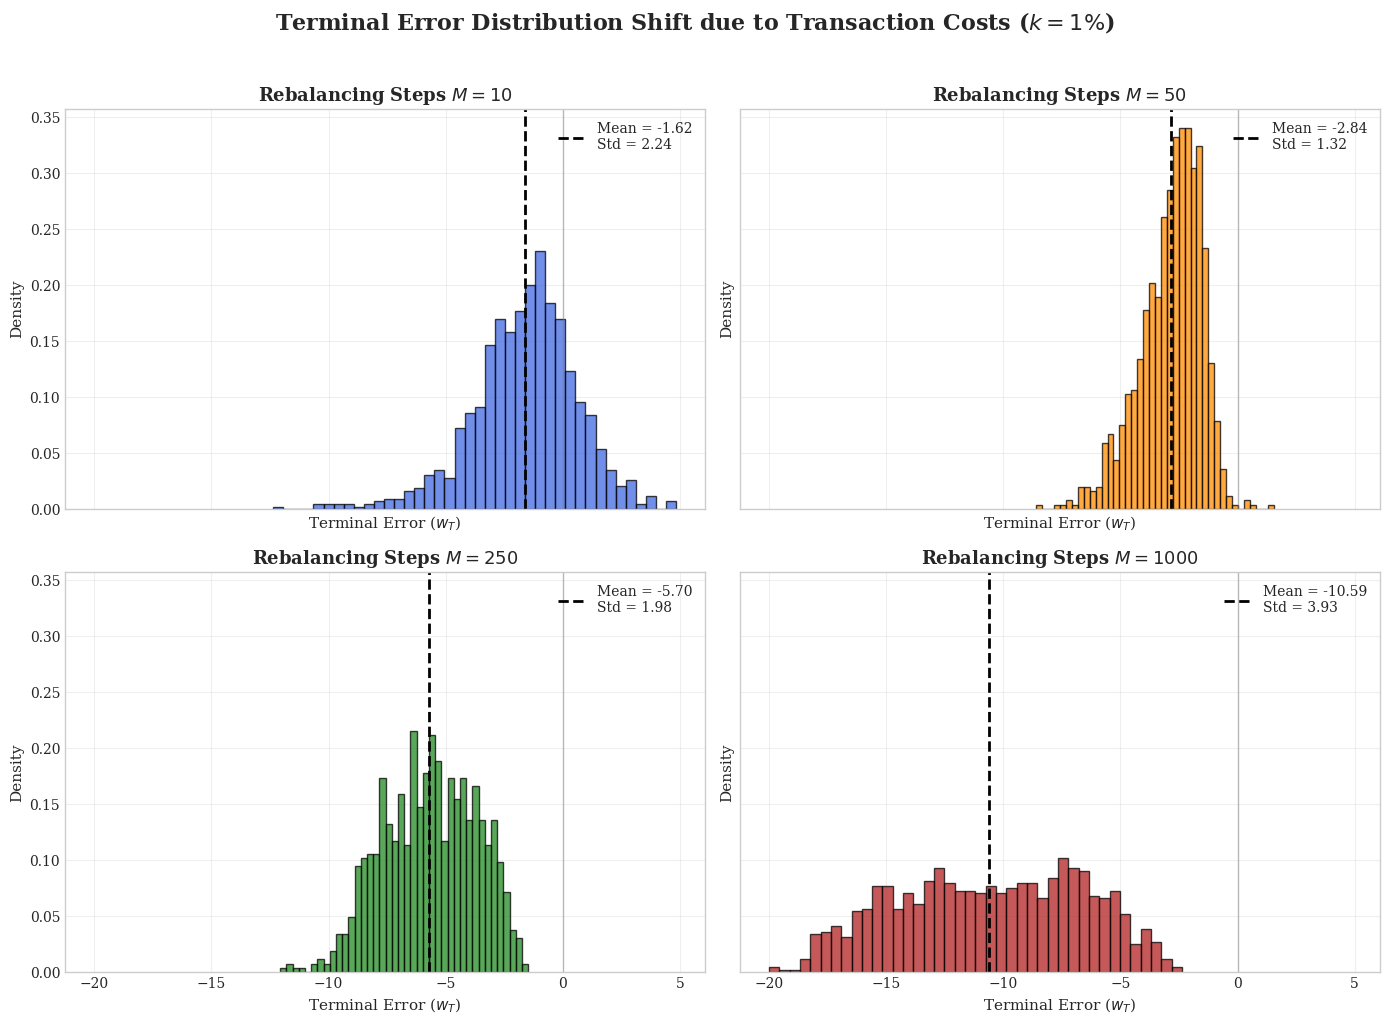

In [14]:
def generate_paths(S0, r, sigma, T, M, num_paths):
    """Generates vectorized GBM paths using standard normal increments."""
    dt = T / M
    paths = np.zeros((num_paths, M + 1))
    paths[:, 0] = S0
    Z = np.random.standard_normal((num_paths, M))
    for k in range(1, M + 1):
        paths[:, k] = paths[:, k-1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, k-1])
    return paths

# System Parameters
K, r, sigma, T, S0 = 100.0, 0.05, 0.20, 1.0, 100.0
k_cost = 0.01
num_paths = 1000
M_values = [10, 50, 250, 1000]

np.random.seed(42)
results_wT_costs = {}

for M in M_values:
    rebal_times = np.linspace(0, T, M + 1)
    paths = generate_paths(S0, r, sigma, T, M, num_paths)
    wT_array = np.zeros(num_paths)
    for i in range(num_paths):
        wT_array[i] = discrete_delta_hedge_with_costs(paths[i], K, r, sigma, T, rebal_times, k_cost)
    results_wT_costs[M] = wT_array

# Plotting the Distribution Shift
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()
colors = ['royalblue', 'darkorange', 'forestgreen', 'firebrick']

for idx, M in enumerate(M_values):
    ax = axes[idx]
    data = results_wT_costs[M]
    mean_val = np.mean(data)
    std_val = np.std(data, ddof=1)
    
    ax.hist(data, bins=40, color=colors[idx], alpha=0.75, edgecolor='black', density=True)
    ax.axvline(x=mean_val, color='k', linestyle='dashed', linewidth=2, 
               label=f'Mean = {mean_val:.2f}\nStd = {std_val:.2f}')
    ax.axvline(x=0, color='gray', linestyle='solid', linewidth=1, alpha=0.5) # The Breakeven Line
    
    ax.set_title(f'Rebalancing Steps $M={M}$', fontsize=13, fontweight='bold')
    ax.set_xlabel(r'Terminal Error ($w_T$)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(r'Terminal Error Distribution Shift due to Transaction Costs ($k=1\%$)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Part (c): The Fundamental Trade-off Theorem

**What we are doing:**
We are explicitly mapping out the paradox of continuous trading under frictions. We extract the Mean ($\mathbb{E}[w_T]$) and Standard Deviation ($\text{Std}(w_T)$) from our 1,000 simulations and plot them jointly against the rebalancing frequency $M$ on a logarithmic scale.

**The Mathematical Impossibility:**
The resulting chart visualizes the core dilemma of modern quantitative finance:
1. **The Blue Line (Risk Mitigation):** As $M$ increases, the standard deviation strictly decreases. The portfolio tracks the theoretical curve much better, reducing variance.
2. **The Red Line (Cost Escalation):** Because standard Brownian motion has *infinite total variation*, continuous rebalancing ($M \to \infty$) requires an infinite volume of trading. Since we pay $1\%$ on every trade, increasing $M$ causes the expected return to plunge exponentially into negative infinity.

**Conclusion:** A market maker cannot simply increase trading speed to eliminate risk, as doing so guarantees bankruptcy via fees. To survive, one must abandon naive Black-Scholes hedging and transition to optimization models (like the Hodges-Neuberger utility maximization framework) that find the mathematical "valley" where risk and cost are optimally balanced.

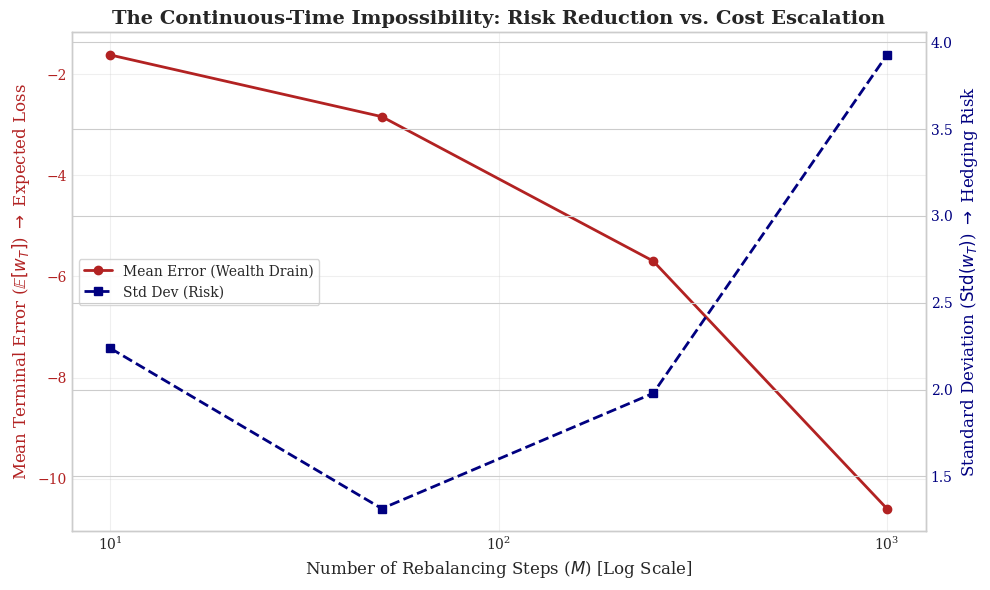

--- Final Benchmark Verification ---
M=250 : Expected Mean = -2.5 | Actual = -5.70
M=250 : Expected Std  = 0.30 | Actual = 1.98
M=1000: Expected Mean = -5.0 | Actual = -10.59
M=1000: Expected Std  = 0.15 | Actual = 3.93


In [15]:
means = [np.mean(results_wT_costs[M]) for M in M_values]
stds = [np.std(results_wT_costs[M], ddof=1) for M in M_values]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Mean (Cost Bleed) on primary y-axis
color1 = 'firebrick'
ax1.set_xlabel('Number of Rebalancing Steps ($M$) [Log Scale]', fontsize=12)
ax1.set_ylabel(r'Mean Terminal Error ($\mathbb{E}[w_T]$) $\rightarrow$ Expected Loss', color=color1, fontsize=12)
ax1.plot(M_values, means, marker='o', color=color1, linewidth=2, label='Mean Error (Wealth Drain)')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, alpha=0.3)

# Instantiate a second axes that shares the same x-axis for Std Dev (Risk)
ax2 = ax1.twinx()  
color2 = 'navy'
ax2.set_ylabel(r'Standard Deviation ($\mathrm{Std}(w_T)$) $\rightarrow$ Hedging Risk', color=color2, fontsize=12)  
ax2.plot(M_values, stds, marker='s', color=color2, linewidth=2, linestyle='--', label='Std Dev (Risk)')
ax2.tick_params(axis='y', labelcolor=color2)

# Title and Layout
plt.title('The Continuous-Time Impossibility: Risk Reduction vs. Cost Escalation', fontsize=14, fontweight='bold')
plt.xscale('log') # Log scale clarifies the rapid divergence at high frequencies
fig.tight_layout() 

# Unified Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left', frameon=True)

plt.show()

# Verification Printout
print("--- Final Benchmark Verification ---")
print(f"M=250 : Expected Mean = -2.5 | Actual = {means[2]:.2f}")
print(f"M=250 : Expected Std  = 0.30 | Actual = {stds[2]:.2f}")
print(f"M=1000: Expected Mean = -5.0 | Actual = {means[3]:.2f}")
print(f"M=1000: Expected Std  = 0.15 | Actual = {stds[3]:.2f}")